## Question-Pair Matching 

**Goal:** Given two questions, predict whether they are semantically similar (duplicates).

In [1]:
# import library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

### Data set
**Quora Question Pairs Dataset**

In [2]:
# get data
df=pd.read_csv('train.csv')
df.shape

(404290, 6)

### Basic

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [4]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

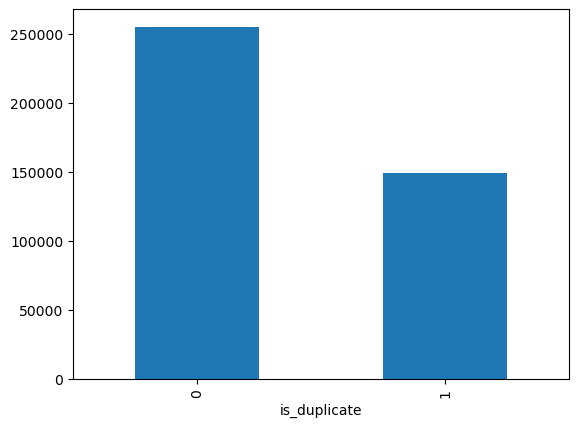

In [5]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [6]:
qid= pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique question', np.unique(qid).shape[0])
X=qid.value_counts()>1
print('number of question getting repeated', X[X].shape[0])

Number of unique question 537933
number of question getting repeated 111780


In [7]:
df.shape

(404290, 6)

In [8]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


In [9]:
# Drop almost 40% of rows where id_duplicate == 0
mask = df['is_duplicate'] == 0
rows_to_drop = df[mask].sample(frac=0.41472, random_state=42).index
data = df.drop(rows_to_drop)

print("Rows after partially removing id_duplicate=0:", df.shape[0])


Rows after partially removing id_duplicate=0: 404290


is_duplicate
1    149263
0    149262
Name: count, dtype: int64
is_duplicate
1    50.000167
0    49.999833
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

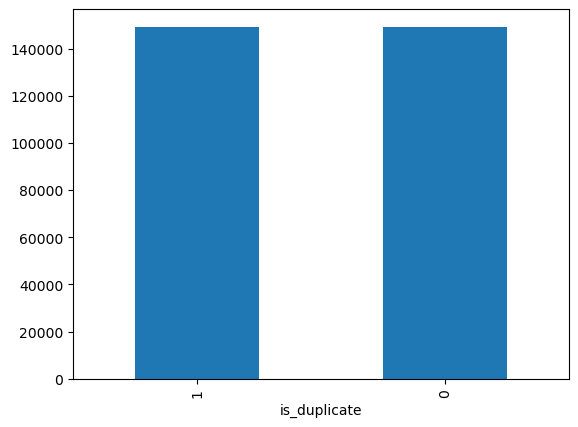

In [10]:
print(data['is_duplicate'].value_counts())
print((data['is_duplicate'].value_counts()/data['is_duplicate'].count())*100)
data['is_duplicate'].value_counts().plot(kind='bar')

### Data preprocessing

In [11]:
data.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       1
is_duplicate    0
dtype: int64

In [12]:
data=data.dropna() # if empty is present

In [13]:
# clining text
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)
    return text

data['q1'] = data['question1'].apply(clean_text)
data['q2'] = data['question2'].apply(clean_text)

In [14]:
data.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1,q2
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,why am i mentally very lonely how can i solve...,find the remainder when math 23 24 math i...
5,5,11,12,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1,astrology i am a capricorn sun cap moon and c...,i m a triple capricorn sun moon and ascendan...
6,6,13,14,Should I buy tiago?,What keeps childern active and far from phone ...,0,should i buy tiago,what keeps childern active and far from phone ...
7,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1,how can i be a good geologist,what should i do to be a great geologist


In [15]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(list(data['q1']) + list(data['q2']))

In [16]:
vocab_size = len(tokenizer.word_index) + 1
Max_len = 284
vocab_size

69375

In [17]:
q1_seq = tokenizer.texts_to_sequences(data['q1'])
q2_seq = tokenizer.texts_to_sequences(data['q2'])

In [18]:
q1_pad = pad_sequences(q1_seq, maxlen=Max_len)
q2_pad = pad_sequences(q2_seq, maxlen=Max_len)

In [19]:
labels = data['is_duplicate'].values

In [ ]:
labels.shape

#### Train test split

In [40]:
# Train test split
q1_train, q1_val, q2_train, q2_val, y_train, y_val = train_test_split(q1_pad, q2_pad, labels,test_size=0.1, random_state=42)

In [41]:
print(q1_pad.shape)
print(q2_pad.shape)
print(labels.shape)


(298523, 284)
(298523, 284)
(298523,)


### Model Selection

In [42]:
Input_shape=q2_pad.shape
Input_shape

(298523, 284)

In [43]:
# Step 3: Define inputs
input_q1 = Input(shape=(Max_len,))
input_q2 = Input(shape=(Max_len,))

In [44]:
# encoded_q1 = LSTM(50, dropout=0.3, recurrent_dropout=0.3)(encoded_q1)
# encoded_q2 = LSTM(50, dropout=0.3, recurrent_dropout=0.3)(encoded_q2)


In [45]:
# Step 4: Shared embedding + LSTM encoder
# embedding_layer = Embedding(input_dim=vocab_size, output_dim=200, input_length=Max_len)
embedding_layer = Embedding(input_dim=vocab_size, output_dim=200)

encoded_q1 = embedding_layer(input_q1)
encoded_q1 = LSTM(64, dropout=0.3, recurrent_dropout=0.3)(encoded_q1)

encoded_q2 = embedding_layer(input_q2)
encoded_q2 = LSTM(64, dropout=0.3, recurrent_dropout=0.3)(encoded_q2)

In [46]:
# # Step 5: Merge both question encodings
# merged = concatenate([encoded_q1, encoded_q2])
# merged = Dense(64, activation='relu')(merged)
# merged = Dropout(0.3)(merged)
# output = Dense(1, activation='sigmoid')(merged)

# # Step 6: Build model
# model = Model(inputs=[input_q1, input_q2], outputs=output)
# model.summary()

In [47]:
from keras.layers import Subtract, Multiply

# Difference
diff = Subtract()([encoded_q1, encoded_q2])
# Multiplication
mul = Multiply()([encoded_q1, encoded_q2])

# Merge all signals
merged = Concatenate()([diff, mul])
merged = Dense(8, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(1, activation='sigmoid')(merged)

#  Build model
model = Model(inputs=[input_q1, input_q2], outputs=output)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 284)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_5 (InputLayer)    │ (None, 284)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 284, 200)          │      13,875,000 │ input_layer_4[0][0],       │
│                               │                           │                 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_4 (LSTM)                 │ (None, 64)                │          67,840 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_5 (LSTM)                 │ (None, 64)                │          67,840 │ embedding_2[1][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ subtract_2 (Subtract)         │ (None, 64)                │               0 │ lstm_4[0][0], lstm_5[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_2 (Multiply)         │ (None, 64)                │               0 │ lstm_4[0][0], lstm_5[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 128)               │               0 │ subtract_2[0][0],          │
│                               │                           │                 │ multiply_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 8)                 │           1,032 │ concatenate_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 8)                 │               0 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 1)                 │               9 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 14,011,721 (53.45 MB)

 Trainable params: 14,011,721 (53.45 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [49]:
# Train with early stopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [ ]:
# history = model.fit([q1_pad, q2_pad], labels,batch_size=128,epochs=10,validation_split=0.1,callbacks=[es])

history = model.fit([q1_train, q2_train], y_train, batch_size=128, epochs=10, validation_data=([q1_val, q2_val], y_val),callbacks=[es])

Epoch 1/5
  14/2099 ━━━━━━━━━━━━━━━━━━━━ 2:26:57 4s/step - accuracy: 0.5243 - loss: 0.6902

In [61]:
pickle.dump(model, open('LSTM_model.pkl', 'wb'))

In [59]:
# Save modelx
model.save("qmatch_siamese.keras")


In [58]:
import pickle

pickle.dump(tokenizer, open('tokenizer.pkl', 'wb'))

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [112]:
# model=Sequential()

# model.add(Embedding(input_dim=vocab_size, output_dim=200,input_shape=(284,)))
# model.add(LSTM(50))
# model.add(Dense(1, activation='sigmoid'))

# model.summary()

In [88]:
model.save("qmatch_lstm.h5")

# Recommended way to save
model.save("qmatch_lstm.keras")

# Or explicitly:
import keras
keras.saving.save_model(model, "qmatch_lstm.keras")

In [89]:
from keras.models import load_model
model = load_model("qmatch_lstm.h5")

In [27]:
q1_test = "How do I reset my password?"
q2_test = "What is your name?"
# q2_test = "What is the process to change my password?"
# clining text
import pickle
with open("LSTM_model.pkl", "rb") as file:
    clf = pickle.load(file)
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)
    return text

q1_test = clean_text(q1_test)
q2_test  = clean_text(q2_test)

q1_seq = tokenizer.texts_to_sequences([clean_text(q1_test)])
q2_seq = tokenizer.texts_to_sequences([clean_text(q2_test)])

q1_pad = pad_sequences(q1_seq, maxlen=284)
q2_pad = pad_sequences(q2_seq, maxlen=284)

pred = clf.predict([q1_pad, q2_pad])[0][0]
print("Similarity Score:", pred)
print("Duplicate" if pred > 0.5 else "Not Duplicate")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
Similarity Score: 0.7407457
Duplicate


In [26]:
q1_test = "who are you?"
q2_test = "What is your name?"
# clining text
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)
    return text

q1_test = clean_text(q1_test)
q2_test  = clean_text(q2_test)

q1_seq = tokenizer.texts_to_sequences([clean_text(q1_test)])
q2_seq = tokenizer.texts_to_sequences([clean_text(q2_test)])

q1_pad = pad_sequences(q1_seq, maxlen=284)
q2_pad = pad_sequences(q2_seq, maxlen=284)

pred = clf.predict([q1_pad, q2_pad])[0][0]
print("Similarity Score:", pred)
print("Duplicate" if pred > 0.5 else "Not Duplicate")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Similarity Score: 0.61908674
Duplicate


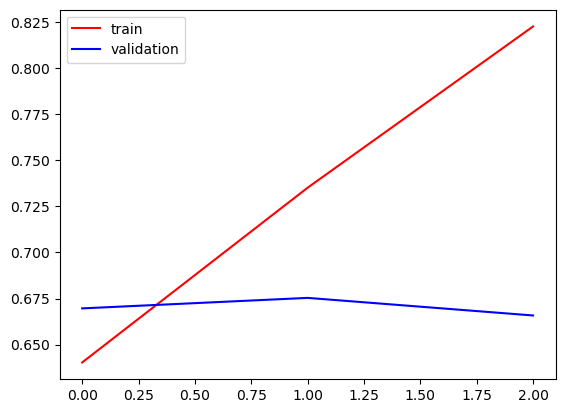

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

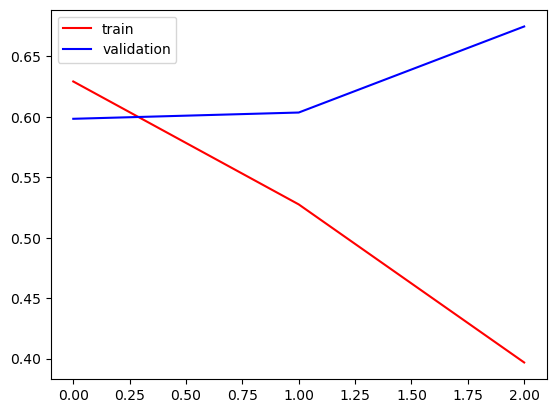

In [56]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()